# Post-filter QC

Visualizes QC histograms post-filtering

In [1]:
import sys
from pathlib import Path
import os
import scanpy as sc
import matplotlib.pyplot as plt
import math
import warnings
import session_info

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = os.path.join(base_dir, 'data/h5ad/export_02')
fig_dir = os.path.join(base_dir, 'figures/qc/')
os.makedirs(fig_dir, exist_ok=True)

In [4]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi.h5ad'))

In [5]:
adata.obs.output_id.value_counts()

output_id
TMA00305    31771
TMA00306    30839
TMA00304    20395
TMA00303    10849
Name: count, dtype: int64

In [6]:
adata.X = adata.layers['counts'].copy()

In [7]:
output_ids = adata.obs['output_id'].unique()

TMA00304
20395 cells
TMA00306
30839 cells
TMA00303
10849 cells
TMA00305
31771 cells


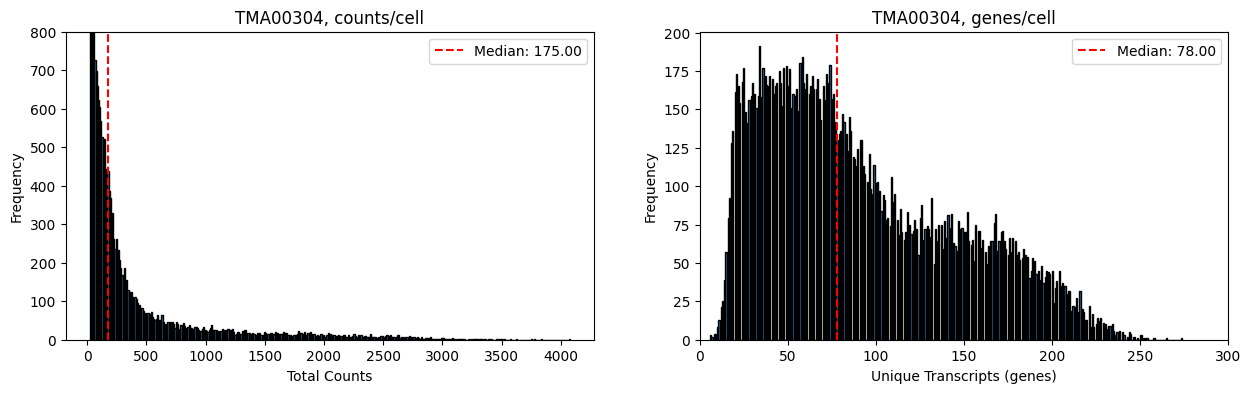

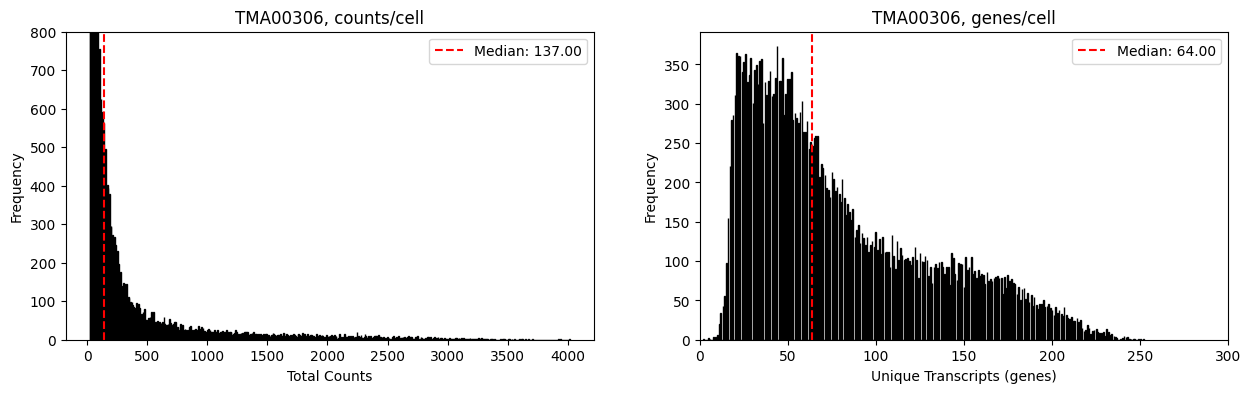

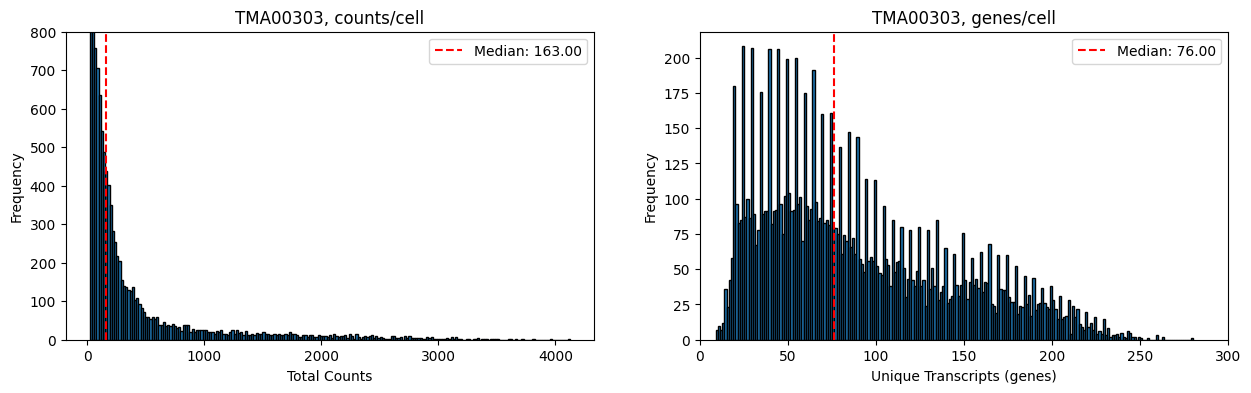

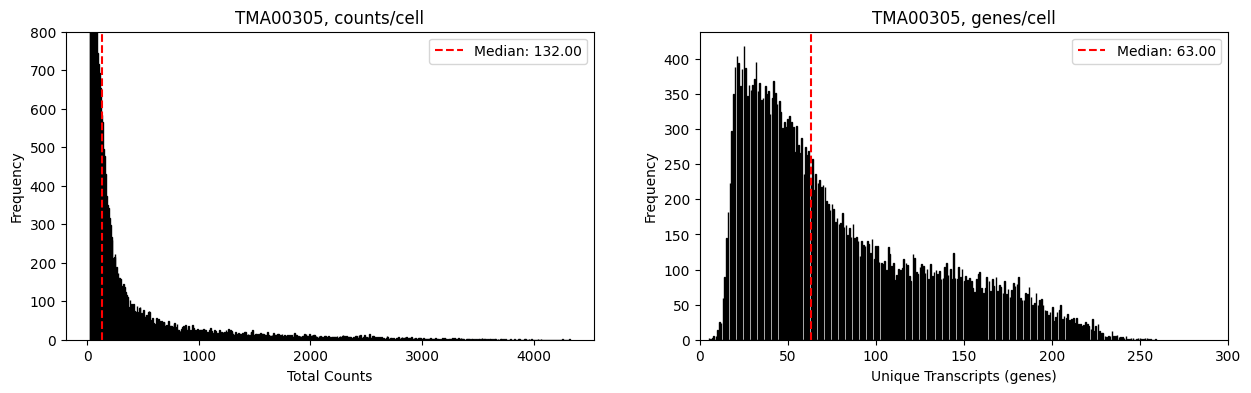

In [8]:
for output_id in output_ids:
    # Filter data for the current sample
    adata_sample = adata[adata.obs['output_id'] == output_id]
    print(output_id)

    # Number of cells
    cell_num = adata_sample.obs.shape[0]
    print(cell_num, 'cells')

    # Visualize QC
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    # Plot the first histogram: Total Counts
    counts_median = adata_sample.obs["total_counts"].median()  
    axs[0].hist(adata_sample.obs["total_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[0].set_title(f"{output_id}, counts/cell")
    #axs[0].set_xlim(0, 1000)
    axs[0].set_ylim(0, 800)
    axs[0].set_xlabel('Total Counts')
    axs[0].set_ylabel('Frequency')
    axs[0].axvline(counts_median, color='red', linestyle='--', label=f'Median: {counts_median:.2f}')  
    axs[0].legend()  

    # Plot the second histogram: Genes by Counts
    genes_median = adata_sample.obs["n_genes_by_counts"].median()  
    axs[1].hist(adata_sample.obs["n_genes_by_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[1].set_title(f"{output_id}, genes/cell")
    axs[1].set_xlim(0, 300)
    axs[1].set_xlabel('Unique Transcripts (genes)')
    axs[1].set_ylabel('Frequency')
    axs[1].axvline(genes_median, color='red', linestyle='--', label=f'Median: {genes_median:.2f}')  
    axs[1].legend()

    # Save figure
    fig.savefig(os.path.join(fig_dir, f"{output_id}_filtered_QC.png"))

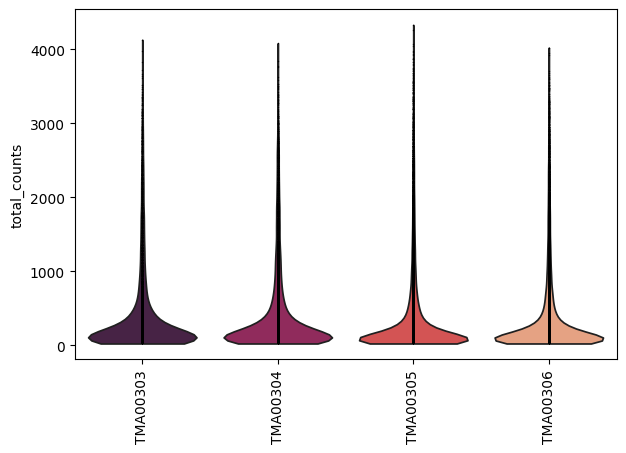

In [9]:
sc.pl.violin(adata, keys='total_counts', groupby='output_id', jitter=False, palette = 'rocket', rotation = 90)

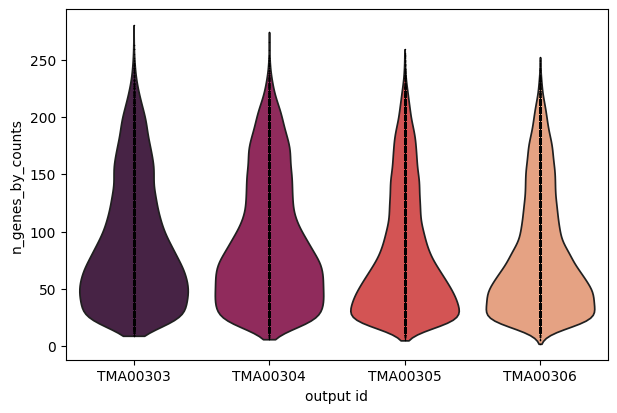

In [10]:
sc.pl.violin(adata, keys='n_genes_by_counts', groupby='output_id', jitter=False, palette = 'rocket')

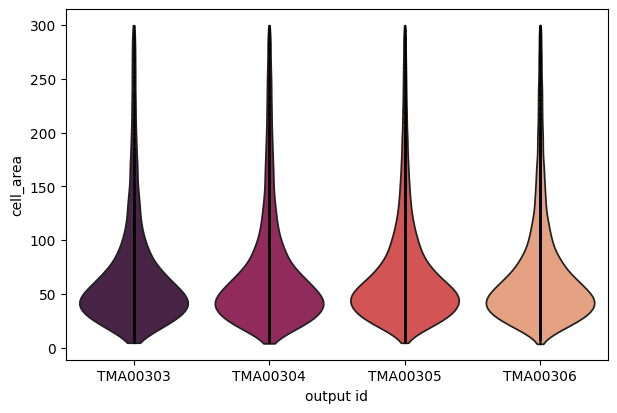

In [11]:
sc.pl.violin(adata, keys='cell_area', groupby='output_id', jitter=False, palette = 'rocket')

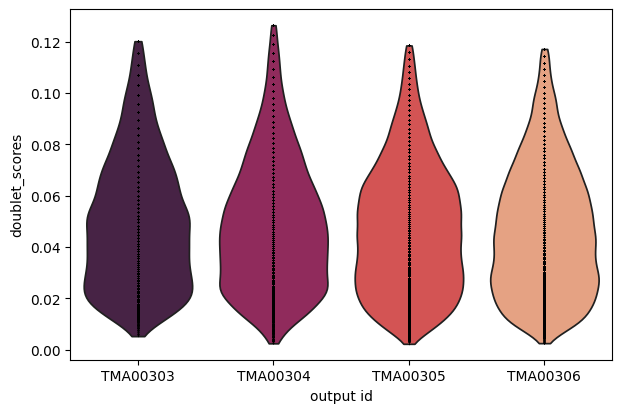

In [12]:
sc.pl.violin(adata, keys='doublet_scores', groupby='output_id', jitter=False, palette = 'rocket')

### Session info

In [13]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
